# NVIDIA ALCHEMI BMD: UDC-Inspired Conformer Stability Scoring

This playbook demonstrates a conformer stability scoring workflow inspired by
Universal Display Corporation (UDC), who used NVIDIA ALCHEMI to screen OLED materials
for thermal processing stability at **10,000× DFT speedup**.

Using the **Batched Molecular Dynamics (BMD)** NIM endpoint, we generate conformers
of a candidate molecule, run batched NVT simulations at elevated temperature, and
score thermal stability from energy statistics.

## What You Will Learn

1. **Connect** to the ALCHEMI BMD endpoint and verify availability
2. **Generate conformers** for a candidate organic molecule (naphthalene)
3. **Build gas-phase simulation cells** with periodic boundary conditions
4. **Run batched NVT MD** at elevated temperature via the REST API
5. **Score conformer stability** using energy statistics (variance, drift)
6. **Compare conformers** and identify the most thermally stable geometry

> **Prerequisites**
>
> - NVIDIA ALCHEMI BMD NIM running on `localhost:$BMD_PORT` **or** cached responses in `cached_responses/`
> - Python ≥ 3.11 with packages from `environment.yml`
> - ~2 min for FAST_DEMO, ~10 min for full production runs

---
## 1. Environment Setup & Control Panel

In [1]:
# --- Imports and version check ---
import sys
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ase.io

warnings.filterwarnings("ignore", category=DeprecationWarning)

_missing = []
for _pkg in ["ase", "pydantic", "requests"]:
    try:
        __import__(_pkg)
    except ImportError:
        _missing.append(_pkg)

if _missing:
    print(f"Missing packages: {_missing}")
    print("Install with: pip install " + " ".join(_missing))
else:
    from importlib.metadata import version as _pkg_version

    print("All required packages available.")
    print(f"  ASE {_pkg_version('ase')}")
    print(f"  pydantic {_pkg_version('pydantic')}")

All required packages available.
  ASE 3.27.0
  pydantic 2.12.5


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                      CONTROL PANEL                             ║
# ║  Adjust these parameters to control simulation behaviour.      ║
# ╚══════════════════════════════════════════════════════════════════╝

# --- Demo mode ---
FAST_DEMO = False  # True: short sims + cached responses

# --- Endpoint ---
BMD_PORT = 8000
BMD_SERVER_URL = f"http://localhost:{BMD_PORT}"

# --- MD parameters ---
DT_FS = 1.0  # Integration timestep (fs)
FRICTION = 1.0  # Langevin friction (ps⁻¹)
SEED = 42  # RNG seed for reproducibility

# --- UDC workflow parameters ---
T_UDC = 500.0  # Elevated temperature for stability test (K)
N_CONFORMERS = 3  # Number of conformers to generate
PERTURBATION_STD = 0.05  # Gaussian noise std dev for conformer generation (Å)
BOX_SIZE = 50.0  # Vacuum box side length (Å)
NSTEPS_UDC = 200 if FAST_DEMO else 2000  # MD steps per conformer
SAVE_INTERVAL = 5 if FAST_DEMO else 50  # Save trajectory every N steps

# --- Paths ---
CACHE_DIR = "cached_responses"
OUTPUT_DIR = "outputs"
STRUCTURE_DIR = "structures"

print(f"FAST_DEMO = {FAST_DEMO}")
print(f"UDC temperature: {T_UDC} K | Steps: {NSTEPS_UDC}")
print(f"Conformers: {N_CONFORMERS} | Box: {BOX_SIZE} Å")

FAST_DEMO = False
UDC temperature: 500.0 K | Steps: 2000
Conformers: 3 | Box: 50.0 Å


In [3]:
# --- Helper imports and directory setup ---
sys.path.insert(0, ".")
from helpers import (
    MDAtomicData,
    MDConfig,
    MDRequest,
    check_endpoint,
    run_md_or_load_cache,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
print("Helpers loaded. Output directories ready.")

Helpers loaded. Output directories ready.


---
## 2. Endpoint Connectivity & API Hello World

Before running simulations we verify the BMD NIM is reachable. If it isn’t, every
subsequent cell will fall back to cached responses (when `FAST_DEMO = True`).

In [4]:
BMD_ENDPOINT_LIVE = check_endpoint(BMD_SERVER_URL)
if BMD_ENDPOINT_LIVE:
    print(f"BMD endpoint is LIVE at {BMD_SERVER_URL}")
else:
    print(
        f"BMD endpoint NOT reachable at {BMD_SERVER_URL} — will use cached responses."
    )

BMD endpoint is LIVE at http://localhost:8000


### Request / Response Schema

| Field | Type | Description |
|-------|------|-------------|
| `atoms.coord` | `List[float]` | Flattened xyz coordinates (Å) |
| `atoms.numbers` | `List[int]` | Atomic numbers |
| `atoms.cell` | `List[float]` | 3×3 flattened lattice vectors (Å) |
| `atoms.pbc` | `List[bool]` | Periodic boundary conditions |
| `atoms.velocity` | `List[float]` | Flattened velocities (Å/fs) |
| `config.temperature` | `float` | Target temperature (K) |
| `config.dt` | `float` | Timestep (fs) |
| `config.nvt` / `config.npt` | `bool` | Thermostat / barostat toggles |
| `config.md_time_max` | `float` | Simulation end time (ps) |
| `config.save_interval` | `int` | Frames saved every N steps |
| **Response** | | |
| `trajectory[].energy` | `float` | Potential energy (eV) |
| `trajectory[].coord` | `List[float]` | Updated coordinates |
| `trajectory[].velocity` | `List[float]` | Updated velocities |
| `trajectory[].cell` | `List[float]` | Updated cell (NPT) |
| `trajectory[].stress` | `List[float]` | Virial stress tensor (eV/Å³) |

In [5]:
# --- API Hello World: tiny H2 MD ---
h2_atoms = MDAtomicData(
    coord=[0.0, 0.0, 0.0, 0.0, 0.0, 0.74],
    numbers=[1, 1],
    cell=[10.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 10.0],
    pbc=[True, True, True],
)
h2_config = MDConfig(
    temperature=300.0,
    dt=1.0,
    nvt=True,
    npt=False,
    md_time_max=0.01,  # 10 fs
    save_interval=1,
)

h2_reply = run_md_or_load_cache(
    h2_atoms, h2_config, BMD_SERVER_URL, CACHE_DIR, "h2_hello_world", BMD_ENDPOINT_LIVE
)

print(f"Status      : {h2_reply.status}")
print(f"Frames      : {len(h2_reply.trajectory)}")
print(f"Final energy: {h2_reply.trajectory[-1].energy:.6f} eV")

  Loading cached response: h2_hello_world
Status      : Success
Frames      : 11
Final energy: -6.511127 eV


In [6]:
from IPython.display import JSON

# --- Pretty-print request and first response snapshot ---
request_dict = MDRequest(atoms=h2_atoms, config=h2_config).model_dump()
print("=== BMD REQUEST ===")
JSON(request_dict, expanded=False, root="request")

=== BMD REQUEST ===


<IPython.core.display.JSON object>

In [7]:
print("=== BMD RESPONSE (FIRST MD SNAPSHOT) ===")
md_snapshot_dict = h2_reply.trajectory[0].model_dump()
JSON(md_snapshot_dict, expanded=False, root="response")

=== BMD RESPONSE (FIRST MD SNAPSHOT) ===


<IPython.core.display.JSON object>

---
## 3. Conformer Generation

We demonstrate the UDC workflow using **naphthalene (C₁₀H₈)** — the simplest polycyclic
aromatic hydrocarbon and structural analogue to OLED emitter cores.

The approach:
1. Load a base geometry from an XYZ file
2. Generate perturbed conformers by adding small random displacements
3. Place each conformer in a large periodic box (gas-phase approximation)

<figure style="text-align: center; margin: 1.5em 0;">
  <img src="assets/udc_workflow_diagram.png" alt="UDC OLED virtual screening workflow: BCS NIM generates conformers, BMD NIM predicts thermal stability properties — 10,000× faster than DFT" style="max-width: 100%; border-radius: 4px;" />
  <figcaption style="font-size: 0.9em; color: #555; margin-top: 0.5em;">
    <strong>Figure:</strong> UDC’s two-step virtual screening workflow — BCS NIM generates low-energy conformers, BMD NIM predicts thermal processing stability at 10,000× DFT speedup.
    <br/><em>Source: <a href="https://developer.nvidia.com/blog/faster-chemistry-and-materials-discovery-with-ai-powered-simulations-using-nvidia-alchemi/">NVIDIA Developer Blog</a></em>
  </figcaption>
</figure>

In [8]:
# --- Generate conformers from naphthalene XYZ ---
# Base conformer from file
naph_base = ase.io.read(os.path.join(STRUCTURE_DIR, "naphthalene.xyz"))
print(f"Naphthalene: {naph_base.get_chemical_formula()} — {len(naph_base)} atoms")

# Generate perturbed conformers by adding small random displacements
np.random.seed(SEED)
conformers = [naph_base.copy()]
for i in range(N_CONFORMERS - 1):
    conf = naph_base.copy()
    noise = np.random.normal(0, PERTURBATION_STD, conf.positions.shape)
    conf.positions += noise
    conformers.append(conf)
    print(f"  Conformer {i + 1}: perturbed by ±{PERTURBATION_STD} Å")

print(f"Total conformers: {len(conformers)}")

Naphthalene: C10H8 — 18 atoms
  Conformer 1: perturbed by ±0.05 Å
  Conformer 2: perturbed by ±0.05 Å
Total conformers: 3


In [9]:
# --- Convert conformers to MDAtomicData (large periodic box for gas-phase) ---
large_cell = [BOX_SIZE, 0.0, 0.0, 0.0, BOX_SIZE, 0.0, 0.0, 0.0, BOX_SIZE]

conformer_atoms_list = []
for i, conf in enumerate(conformers):
    # Centre molecule in the box
    centroid = conf.positions.mean(axis=0)
    centred_pos = conf.positions - centroid + BOX_SIZE / 2.0
    md_data = MDAtomicData(
        coord=centred_pos.flatten().tolist(),
        numbers=conf.numbers.tolist(),
        cell=large_cell,
        pbc=[True, True, True],
        structure_id=f"naph_conf_{i}",
    )
    conformer_atoms_list.append(md_data)
    print(f"Conformer {i}: {len(md_data.numbers)} atoms, {BOX_SIZE} Å periodic box")

Conformer 0: 18 atoms, 50.0 Å periodic box
Conformer 1: 18 atoms, 50.0 Å periodic box
Conformer 2: 18 atoms, 50.0 Å periodic box


---
## 4. Batched NVT MD at Elevated Temperature

We run NVT molecular dynamics at elevated temperature (500 K) to test thermal
stability. More stable conformers exhibit lower energy variance and less drift
during the production phase.

> **Note**: The BMD endpoint requires periodic boundary conditions on all structures.
> Non-periodic molecules (like naphthalene) must be placed in a large vacuum box
> (e.g. 50 Å) to prevent self-interaction across periodic images.

In [10]:
# --- Batched NVT MD at elevated T ---
udc_time_ps = NSTEPS_UDC * DT_FS / 1000.0

udc_results = []
for i, md_data in enumerate(conformer_atoms_list):
    label = f"naph_conf{i}_nvt_{int(T_UDC)}K"
    print(f"\n--- Conformer {i} @ {T_UDC} K ---")

    cfg = MDConfig(
        temperature=T_UDC,
        dt=DT_FS,
        nvt=True,
        npt=False,
        friction=FRICTION,
        md_time_max=udc_time_ps,
        save_interval=SAVE_INTERVAL,
    )
    reply = run_md_or_load_cache(
        md_data, cfg, BMD_SERVER_URL, CACHE_DIR, label, BMD_ENDPOINT_LIVE
    )
    udc_results.append((md_data, reply))
    print(
        f"  Frames: {len(reply.trajectory)} | Final E: {reply.trajectory[-1].energy:.4f} eV"
    )


--- Conformer 0 @ 500.0 K ---
  Loading cached response: naph_conf0_nvt_500K
  Frames: 41 | Final E: -117.1554 eV

--- Conformer 1 @ 500.0 K ---
  Loading cached response: naph_conf1_nvt_500K
  Frames: 41 | Final E: -117.4951 eV

--- Conformer 2 @ 500.0 K ---
  Loading cached response: naph_conf2_nvt_500K
  Frames: 41 | Final E: -117.4446 eV


---
## 5. Stability Scoring & Comparison

We score each conformer’s thermal stability using production-phase energy statistics:

- **E_mean**: Mean potential energy (more negative → more bound)
- **E_std**: Energy fluctuation (lower → more stable)
- **E_drift**: Linear energy drift (lower → less degradation)
- **Composite score**: Weighted combination (lower → more stable)

The first 30% of frames are discarded as equilibration.

In [11]:
# --- Stability scoring ---
scores = []
for i, (md_data, reply) in enumerate(udc_results):
    energies = np.array([s.energy for s in reply.trajectory])
    # Discard first 30% as equilibration
    n_equil = int(0.3 * len(energies))
    prod_e = energies[n_equil:]

    e_mean = prod_e.mean()
    e_std = prod_e.std()
    # Energy drift: slope of linear fit
    t_arr = np.arange(len(prod_e), dtype=float)
    drift = np.polyfit(t_arr, prod_e, 1)[0] if len(prod_e) > 1 else 0.0

    # Composite score: lower is more stable
    composite = abs(e_mean) * 0.01 + e_std + abs(drift) * 100
    scores.append(
        {
            "Conformer": i,
            "E_mean (eV)": round(e_mean, 4),
            "E_std (eV)": round(e_std, 4),
            "E_drift (eV/frame)": f"{drift:.2e}",
            "Composite Score": round(composite, 4),
        }
    )

scores_df = pd.DataFrame(scores)
best = scores_df["Composite Score"].idxmin()
print("Stability Scores (lower = more stable):")
display(scores_df)
print(f"\nMost stable conformer: {best}")

Stability Scores (lower = more stable):


,Conformer,E_mean (eV),E_std (eV),E_drift (eV/frame),Composite Score
0,0,-117.5861,0.1778,1.39e-02,2.7389
1,1,-117.3527,0.2013,-1.02e-02,2.3949
2,2,-117.3330,0.2165,1.22e-02,2.6111



Most stable conformer: 1


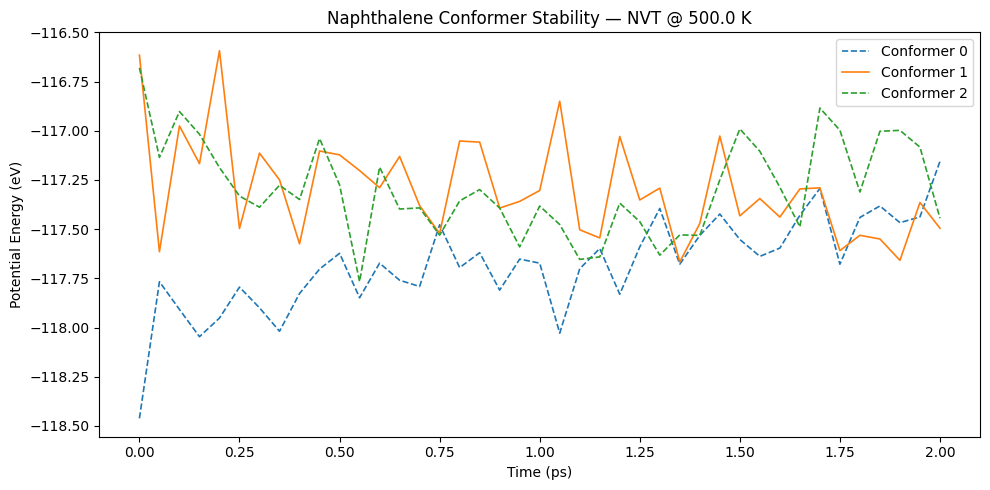

In [12]:
# --- Energy evolution comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
for i, (md_data, reply) in enumerate(udc_results):
    energies = [s.energy for s in reply.trajectory]
    times = [s.md_time for s in reply.trajectory]
    style = "-" if i == best else "--"
    ax.plot(times, energies, style, lw=1.2, label=f"Conformer {i}")

ax.set(
    xlabel="Time (ps)",
    ylabel="Potential Energy (eV)",
    title=f"Naphthalene Conformer Stability — NVT @ {T_UDC} K",
)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "udc_conformer_energy.png"), dpi=150)
plt.show()

---
## 6. Scaling to Production

In production, UDC runs this workflow at scale:
- **Thousands of candidates** from generative chemistry → RDKit conformer generation
- **Batched BMD requests** using `asyncio` (see `examples/bgr_script.py`)
- **Multiple MLIP models** for consensus scoring
- **10,000× speedup** over DFT for thermal stability prediction

The single-endpoint design means switching from research (small batch, single model)
to production (large batch, model ensemble) requires no code changes.

---
## 7. Summary

In this playbook we demonstrated:

1. **Endpoint connectivity** — health check, schema walkthrough, H₂ hello world
2. **Conformer generation** — naphthalene base geometry + random perturbations
3. **Gas-phase simulation cells** — large periodic vacuum boxes for non-periodic molecules
4. **Batched NVT MD** — elevated temperature simulations via the BMD REST API
5. **Stability scoring** — energy statistics for conformer ranking

### Next Steps

- **Real conformers**: Use RDKit’s `EmbedMultipleConfs` for physically meaningful conformer sampling
- **Larger molecules**: Apply to real OLED emitter candidates (e.g. Ir(ppy)₃)
- **Materials MD**: See the companion playbook `alchemi-playbook-nims.ipynb` for crystalline NaCl thermodynamic analysis
- **Switch MLIPs**: Restart the NIM with `--model sevennet` or `--model orb` — no client changes needed
- **Scale up**: Use `asyncio` for concurrent batch submissions